In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
df.shape

(891, 12)

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)

In [11]:
df['Embarked']=df['Embarked'].map({'S':0,'C':1})

In [21]:
df['Sex']=df['Sex'].map({'male':1,'female':0})

In [15]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Age']=df['Age'].fillna(df['Age'].median())

In [23]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0.0
1,1,1,0,38.0,1,0,71.2833,1.0
2,1,3,0,26.0,0,0,7.9250,0.0
3,1,1,0,35.0,1,0,53.1000,0.0
4,0,3,1,35.0,0,0,8.0500,0.0


In [24]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [25]:
X = df.drop('Survived',axis=1)
y = df['Survived']

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda=lda.fit_transform(X_train,y_train)
X_test_lda=lda.transform(X_test)

In [29]:
model = LogisticRegression()
model.fit(X_train_lda,y_train)
y_pred = model.predict(X_test_lda)

In [30]:
print('accuracy_score:',accuracy_score(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('confusion_matrix:',confusion_matrix(y_test,y_pred))

accuracy_score: 0.7932960893854749
classification_report:               precision    recall  f1-score   support

           0       0.80      0.86      0.83       105
           1       0.78      0.70      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

confusion_matrix: [[90 15]
 [22 52]]


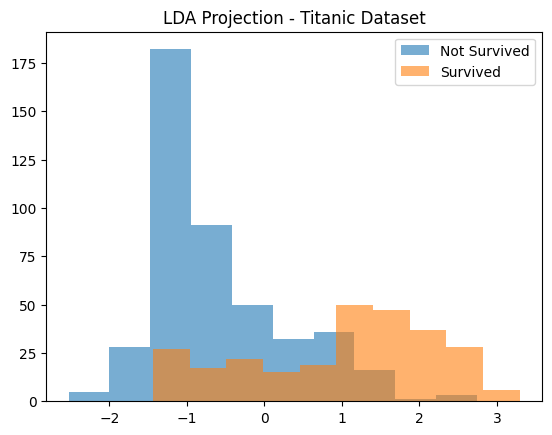

In [31]:
plt.hist(X_train_lda[y_train==0], alpha=0.6,label='Not Survived')
plt.hist(X_train_lda[y_train==1], alpha=0.6,label='Survived')

plt.legend()
plt.title("LDA Projection - Titanic Dataset")
plt.show()

In [32]:
from sklearn.ensemble import RandomForestClassifier

model1 = RandomForestClassifier(n_estimators=200, random_state=42)

model1.fit(X_train_lda, y_train)

y_pred1 = model1.predict(X_test_lda)

In [33]:
print('accuracy_score:',accuracy_score(y_test,y_pred1))
print('classification_report:',classification_report(y_test,y_pred1))
print('confusion_matrix:',confusion_matrix(y_test,y_pred1))

accuracy_score: 0.7262569832402235
classification_report:               precision    recall  f1-score   support

           0       0.77      0.76      0.77       105
           1       0.67      0.68      0.67        74

    accuracy                           0.73       179
   macro avg       0.72      0.72      0.72       179
weighted avg       0.73      0.73      0.73       179

confusion_matrix: [[80 25]
 [24 50]]


In [36]:
from xgboost import XGBClassifier

model2 = XGBClassifier()

model2.fit(X_train_lda, y_train)

y_pred2 = model2.predict(X_test_lda)

In [37]:
print('accuracy_score:',accuracy_score(y_test,y_pred2))
print('classification_report:',classification_report(y_test,y_pred2))
print('confusion_matrix:',confusion_matrix(y_test,y_pred2))

accuracy_score: 0.7988826815642458
classification_report:               precision    recall  f1-score   support

           0       0.79      0.89      0.84       105
           1       0.81      0.68      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

confusion_matrix: [[93 12]
 [24 50]]
